# 04 — Model Training

**Three models, each with a clear justification:**

| Model | Why |
|---|---|
| Logistic Regression | Interpretable baseline; works well on sparse TF-IDF |
| Random Forest | Non-linear ensemble; handles feature interactions |
| SVM (RBF) | Strong literature precedent for text classification |

No LDA, QDA, GBC, or other models — each model added must serve a purpose.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)
import pickle

X_train = sp.load_npz('../data/X_train.npz')
X_test  = sp.load_npz('../data/X_test.npz')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')

label_names = ['Negative', 'Neutral', 'Positive']
majority_baseline = float((y_test == 0).mean())
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Majority class baseline: {majority_baseline:.4f}")

Train: 22008 | Test: 2922
Majority class baseline: 0.6277


## 4.1 Define Models

In [3]:
models = {
    'Logistic Regression': LogisticRegression(
    max_iter=1000, C=1.0,
    solver='lbfgs',
    random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20,
        min_samples_split=3, random_state=42, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        probability=True, random_state=42
    ),
}
print("Models defined.")

Models defined.


## 4.2 5-Fold Stratified Cross-Validation

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<25} {'CV F1 Mean':>12} {'Std':>8}")
print("-" * 48)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>8.4f}")

Model                       CV F1 Mean      Std
------------------------------------------------
Logistic Regression             0.8275   0.0043
Random Forest                   0.7669   0.0068
SVM (RBF)                       0.8738   0.0008


## 4.3 Train and Evaluate on Holdout Test Set

In [5]:
results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = float(accuracy_score(y_test, y_pred))
    f1  = float(f1_score(y_test, y_pred, average='weighted'))

    results[name] = {'accuracy': acc, 'f1': f1, 'y_pred': y_pred}
    trained_models[name] = model

    print(f"\n── {name} ──")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test F1 (wt.) : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_names))


── Logistic Regression ──
  Test Accuracy : 0.7567
  Test F1 (wt.) : 0.7620
              precision    recall  f1-score   support

    Negative       0.88      0.82      0.85      1834
     Neutral       0.53      0.61      0.57       616
    Positive       0.66      0.70      0.68       472

    accuracy                           0.76      2922
   macro avg       0.69      0.71      0.70      2922
weighted avg       0.77      0.76      0.76      2922


── Random Forest ──
  Test Accuracy : 0.6947
  Test F1 (wt.) : 0.7075
              precision    recall  f1-score   support

    Negative       0.85      0.74      0.79      1834
     Neutral       0.43      0.64      0.52       616
    Positive       0.67      0.60      0.63       472

    accuracy                           0.69      2922
   macro avg       0.65      0.66      0.65      2922
weighted avg       0.74      0.69      0.71      2922


── SVM (RBF) ──
  Test Accuracy : 0.7738
  Test F1 (wt.) : 0.7546
              precision

## 4.4 Confusion Matrices

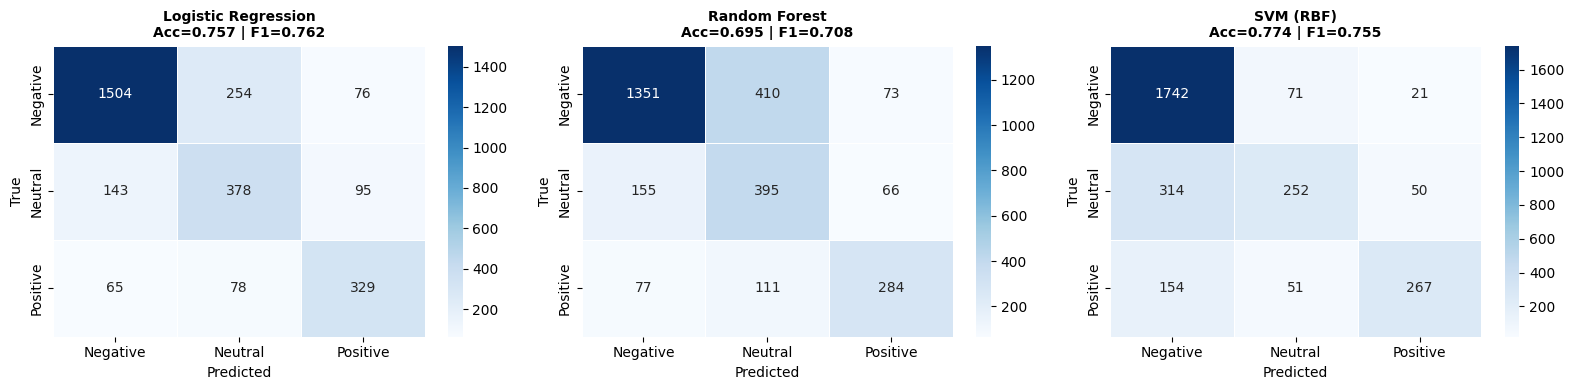

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                cmap='Blues', linewidths=0.5)
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../results/04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Model Comparison vs Baseline

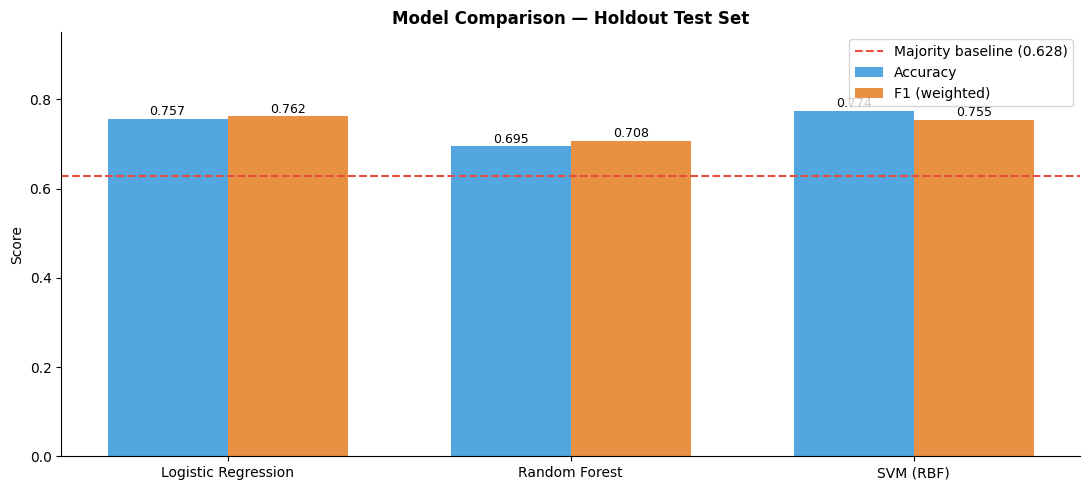

In [7]:
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
f1s   = [results[n]['f1'] for n in names]
x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='#3498db', alpha=0.85)
b2 = ax.bar(x + w/2, f1s,  w, label='F1 (weighted)', color='#e67e22', alpha=0.85)
ax.axhline(majority_baseline, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Majority baseline ({majority_baseline:.3f})')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Holdout Test Set', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 0.95)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Save Best Model

In [8]:
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = trained_models[best_name]
print(f"Best model: {best_name}")
print(f"Test Accuracy: {results[best_name]['accuracy']:.4f}")
print(f"Test F1      : {results[best_name]['f1']:.4f}")

with open('../data/best_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'name': best_name}, f)
print("\nSaved best model to ../data/best_model.pkl")

Best model: Logistic Regression
Test Accuracy: 0.7567
Test F1      : 0.7620

Saved best model to ../data/best_model.pkl
